In [1]:
from ultralytics import YOLO

model = YOLO(
    "../runs/detect/results/yolo/retail_yolo11n/weights/best.pt"
)

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [2]:
test_results = model.val(
    data="../data/processed/yolo/data.yaml",
    split="test",
    imgsz=416,
    batch=4,
    device="cpu",
    workers=0,
    project="../results/yolo",
    name="retail_yolo11n_test"
)

Ultralytics 8.4.172  Python-3.12.0 torch-2.14.1+cpu CPU (13th Gen Intel Core i7-1355U)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 36.021.6 MB/s, size: 37.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\ASUS\Desktop\Retail-CV-Intelligence\data\processed\yolo\labels\test... 86 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 86/86 1.5Kit/s 0.1s
val: New cache created: C:\Users\ASUS\Desktop\Retail-CV-Intelligence\data\processed\yolo\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 7.3it/s 3.0s0.1s
                   all         86        216      0.847      0.844      0.793       0.52
                  aqua         36         36      0.946      0.972      0.987      0.711
              

In [3]:
from pathlib import Path

test_images = list(
    Path("../data/processed/yolo/images/test").glob("*.jpg")
)

len(test_images)

86

In [4]:
test_image = str(test_images[0])

print(test_image)

..\data\processed\yolo\images\test\aqua (1).jpg


In [5]:
results = model.predict(
    source=test_image,
    imgsz=416,
    conf=0.25,
    device="cpu"
)

print("Prediction completed!")


image 1/1 c:\Users\ASUS\Desktop\Retail-CV-Intelligence\notebooks\..\data\processed\yolo\images\test\aqua (1).jpg: 416x416 1 aqua, 56.4ms
Speed: 3.6ms preprocess, 56.4ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 416)
Prediction completed!


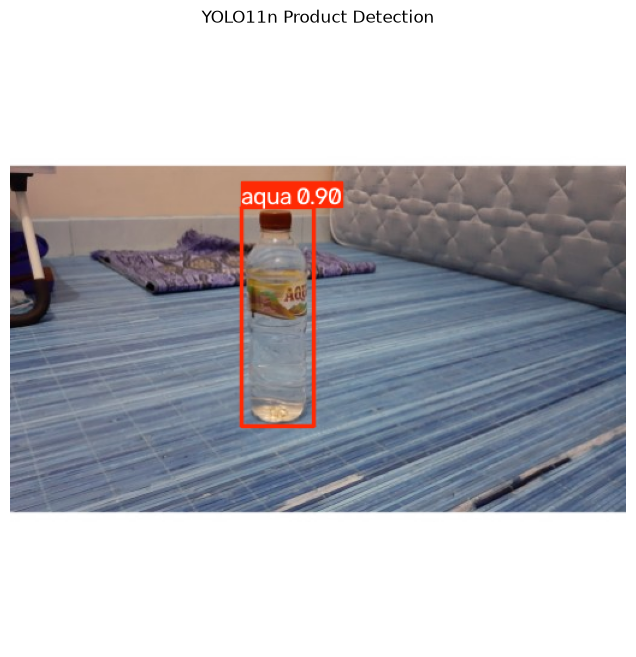

In [6]:
import matplotlib.pyplot as plt

annotated_image = results[0].plot()

plt.figure(figsize=(8, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("YOLO11n Product Detection")
plt.show()

In [7]:
sample_images = test_images[:12]

prediction_results = model.predict(
    source=sample_images,
    imgsz=416,
    conf=0.25,
    device="cpu",
    verbose=False
)

print(f"Predictions completed: {len(prediction_results)}")

Predictions completed: 12


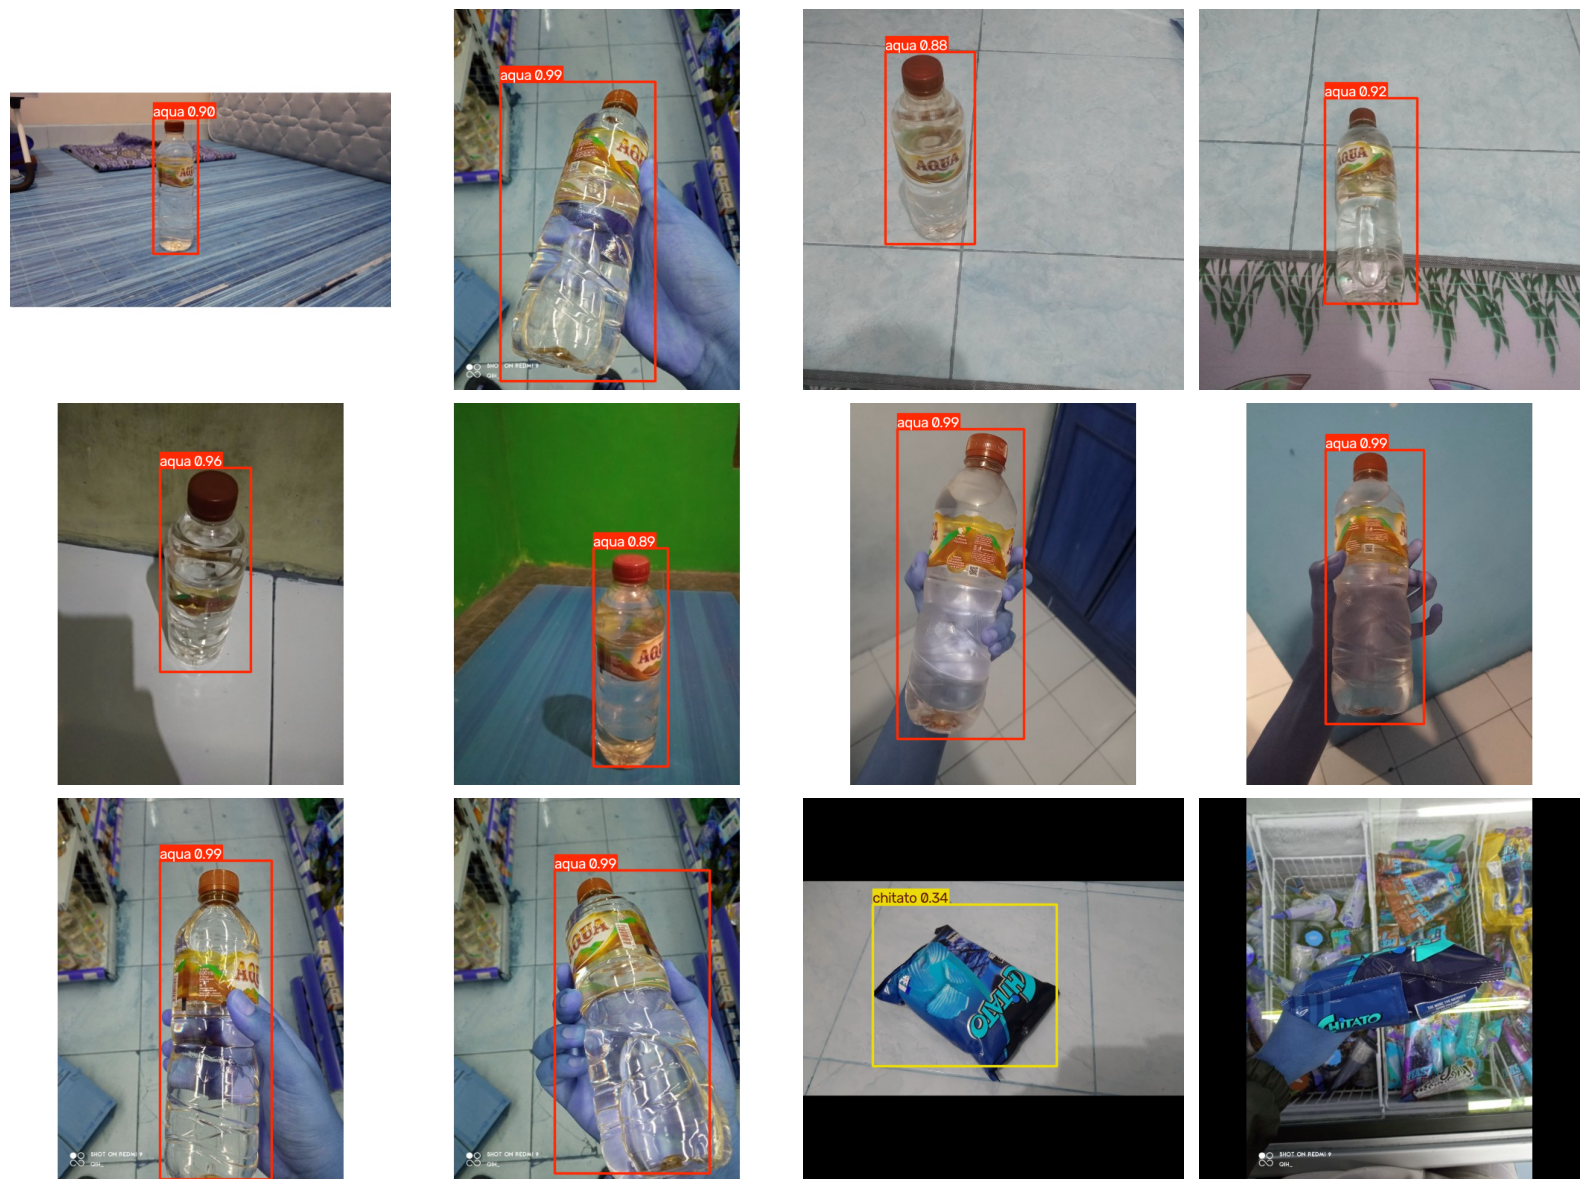

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for ax, result in zip(axes.flatten(), prediction_results):
    annotated = result.plot()

    ax.imshow(annotated)
    ax.axis("off")

plt.tight_layout()
plt.show()